<a href="https://colab.research.google.com/github/AnkiPoppel/Cb2330---Project-/blob/main/PRO1_the_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project card


### The paper:
Cultured Gut Microbiota from Twins Discordant for Obesity Modulate Adiposity and Metabolic Phenotype in Mice

### The data object:

### The random variable chosen:
Change in fat mass after 15 days

###What the paper does:

### The generative model proposed:

### Parameters and assumptions:

### The forward simulation:

### The parameterization/fitting:

### What/if the model adds to the paper:

### Model limitations/how it breaks:


#The Code

In [ ]:
import math
import matplotlib.pyplot as plt


###Random Number Generator

In [ ]:
def lcg(state, a, c, m):
    """Linear Congruental Generator"""
    next_state = (a * state + c) % m
    return next_state

In [ ]:

# The constants.
a = 1664525
c = 1013904223
m = 2 ** 32


def uniforms(k, seed):
    """Random number generator, producing k integers between 0 and 1."""
    out = [0.0] * k
    state = seed
    for i in range(k):
      state = lcg(state, a, c, m)
      out[i] = state /m
    return out

In [ ]:
r = uniforms(20, 123456789)
print (r)
print (type(r))

[0.2142903469502926, 0.8758254086133093, 0.5243400414474308, 0.34355825767852366, 0.5449303174391389, 0.37270335550419986, 0.28888860112056136, 0.5348481752444059, 0.3949666675180197, 0.12831840454600751, 0.4283949160017073, 0.28362571471370757, 0.32885180693119764, 0.29000012460164726, 0.6934705297462642, 0.26959387329407036, 0.9780127853155136, 0.9675452781375498, 0.5401598778553307, 0.8567551171872765]
<class 'list'>


##The change in fat mas per day

In [ ]:
V0 = 0.00001
V_LN = V0
Theta = 0.6666666666667
V_OB = V0 + Theta

Ft_LN = [0] * 10
Ft_OB = [0] * 10

# Populate Ft_LN using the first 10 elements of r
for j in range(10):
  Ft_LN[j] = r[j] + V_LN

# Populate Ft_OB using the next 10 elements of r
for j in range(10):
  Ft_OB[j] = r[j + 10] + V_OB

print (Ft_LN)
print (Ft_OB)

[0.2143003469502926, 0.8758354086133092, 0.5243500414474308, 0.34356825767852367, 0.5449403174391388, 0.3727133555041999, 0.28889860112056137, 0.5348581752444058, 0.3949766675180197, 0.12832840454600752]
[1.0950715826684072, 0.9503023813804076, 0.9955284735978976, 0.9566767912683473, 1.360147196412964, 0.9362705399607704, 1.6446894519822135, 1.6342219448042496, 1.2068365445220306, 1.5234317838539764]


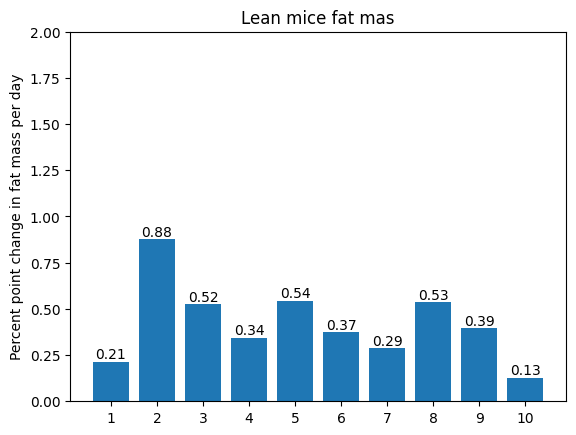

In [ ]:
x_axis = ["1", "2", "3", "4", "5", "6", "7", "8", "9", "10"]



fig, ax = plt.subplots()
bar_container = ax.bar(x_axis, Ft_LN)
ax.set(ylabel='Percent point change in fat mass per day', title='Lean mice fat mas', ylim=(0, 2))
ax.bar_label(bar_container, fmt='{:.2f}')
plt.show()

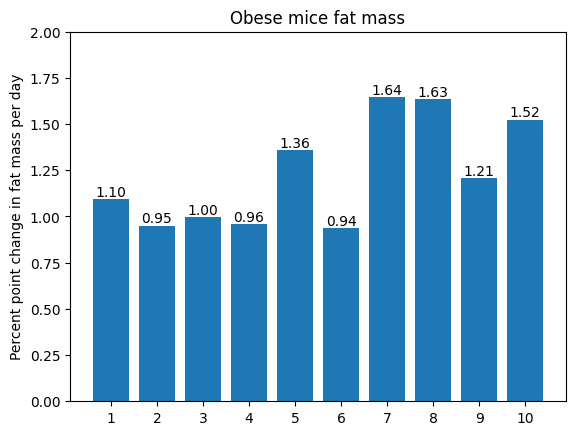

In [ ]:
fig, ax = plt.subplots()
bar_container = ax.bar(x_axis, Ft_OB)
ax.set(ylabel='Percent point change in fat mass per day', title='Obese mice fat mass', ylim=(0, 2))
ax.bar_label(bar_container, fmt='{:.2f}')
plt.show()

##Change in fat mass after 15 days

In [ ]:

Ft_LN_15 = [0] * 10
Ft_OB_15 = [0] * 10

# Ft_LN_15 using the average change per day times 15
for j in range(10):
  Ft_LN_15[j] = (r[j] + V_LN) * 15

# Ft_OB is the average change per day times 15
for j in range(10):
  Ft_OB_15[j] = (r[j + 10] + V_OB) * 15

print (Ft_LN_15)
print (Ft_OB_15)

[3.214505204254389, 13.137531129199639, 7.865250621711462, 5.153523865177855, 8.174104761587083, 5.5907003325629985, 4.333479016808421, 8.022872628666088, 5.924650012770296, 1.9249260681901128]
[16.42607374002611, 14.254535720706114, 14.932927103968465, 14.35015186902521, 20.402207946194462, 14.044058099411556, 24.670341779733203, 24.513329172063745, 18.10254816783046, 22.851476757809646]


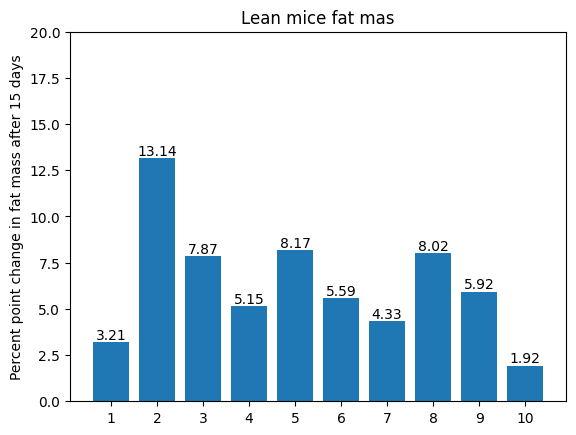

In [ ]:
fig, ax = plt.subplots()
bar_container = ax.bar(x_axis, Ft_LN_15)
ax.set(ylabel='Percent point change in fat mass after 15 days', title='Lean mice fat mas', ylim=(0, 20))
ax.bar_label(bar_container, fmt='{:.2f}')
plt.show()

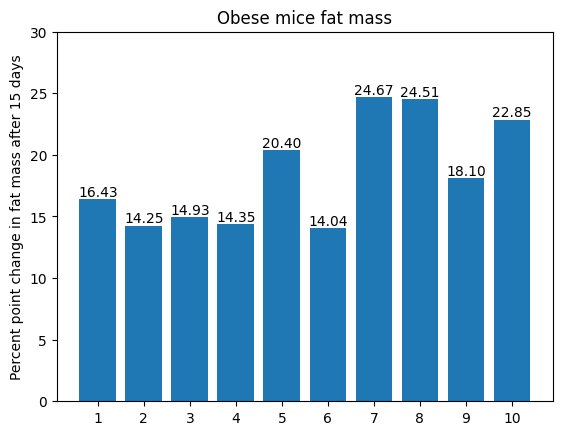

In [ ]:
fig, ax = plt.subplots()
bar_container = ax.bar(x_axis, Ft_OB_15)
ax.set(ylabel='Percent point change in fat mass after 15 days', title='Obese mice fat mass', ylim=(0, 30))
ax.bar_label(bar_container, fmt='{:.2f}')
plt.show()

#Backwards
##NLL

In [ ]:
delta_F_LN = [-16.875, 0.5, -0.341, 0.362, 1.071, -13.125, 2, 0.068, 0.879, -0.429]
N = len(delta_F_LN)

delta_F_OB = [5.625, 3.1, 7.5, 4.655, 7.286, 0, 9, 3.409, 8.276, 5.143]
N = len(delta_F_OB)


def mean(values):
    """Mean"""
    total = 0.0
    for v in values:
        total = total + v
    return total / len(values)


def std(values):
    """Standard deviation"""
    m = mean(values)
    total = 0.0
    for v in values:
        total = total + (v - m) ** 2
    return (total / len(values)) ** 0.5

In [ ]:
print (std(delta_F_LN))
sigma_LN = std(delta_F_LN)
print (std(delta_F_OB))
sigma_OB = std(delta_F_OB)

6.2976798267298415
2.6131235791672767


In [ ]:
print (mean(delta_F_NL))
mu_LN = mean(delta_F_NL)
print (mean(delta_F_OB))
mu_OB = mean(delta_F_OB)

-2.5889999999999995
5.3994


In [ ]:
def normal(x, mu, sigma):
    """f(x | mu, sigma)  the density of a diameter x, in 1/mm."""
    normal = math.exp(-(x-mu)**2/(2*sigma**2))/ (sigma *(2 * math.pi)**0.5)
    return normal


def nll_normal_LN(delta_F_LN, mu, sigma):
    """NLL(mu, sigma) = - the sum over dishes of log f(x_i | mu, sigma)."""
    total = 0.0
    for x in delta_F_LN:
      total_LN += - math.log(normal(x, mu, sigma))
    return total_LN


def nll_normal_OB(delta_F_OB, mu, sigma):
    """NLL(mu, sigma) = - the sum over dishes of log f(x_i | mu, sigma)."""
    total = 0.0
    for x in delta_F_OB:
      total_OB += - math.log(normal(x, mu, sigma))
    return total_OB


nll_LN = nll_normal_LN( delta_F_LN, mu_LN, sigma_LN)

nll_OB = nll_normal_OB(delta_F_OB, mu_OB, sigma_OB)

UnboundLocalError: cannot access local variable 'total_LN' where it is not associated with a value